# **Load data**

Jumlah data: 3654
            BASEL_temp_mean
DATE                       
2000-01-01              2.9
2000-01-02              3.6
2000-01-03              2.2
2000-01-04              3.9
2000-01-05              6.0


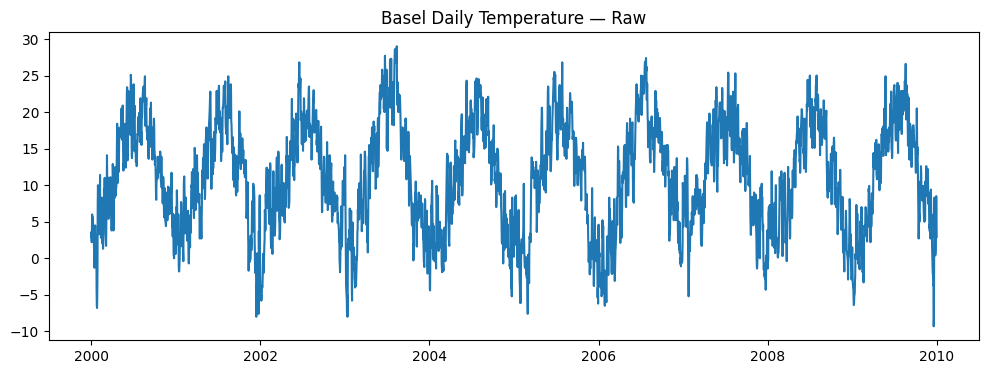

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df = pd.read_csv("clean_basel_temp_mean.csv", parse_dates=["DATE"], index_col="DATE")

print("Jumlah data:", len(df))
print(df.head())

plt.figure(figsize=(12,4))
plt.plot(df["BASEL_temp_mean"])
plt.title("Basel Daily Temperature — Raw")
plt.show()


# **potong data menjadi 2 tahun terakhir**

In [ ]:
df_2yr = df.loc[df.index >= df.index.max() - pd.DateOffset(years=2)]

print(df_2yr.head())
print(df_2yr.tail())


            BASEL_temp_mean
DATE                       
2008-01-01             -0.5
2008-01-02             -1.4
2008-01-03             -0.5
2008-01-04             -0.3
2008-01-05              6.3
            BASEL_temp_mean
DATE                       
2009-12-28              3.2
2009-12-29              4.5
2009-12-30              8.5
2009-12-31              6.6
2010-01-01              2.9


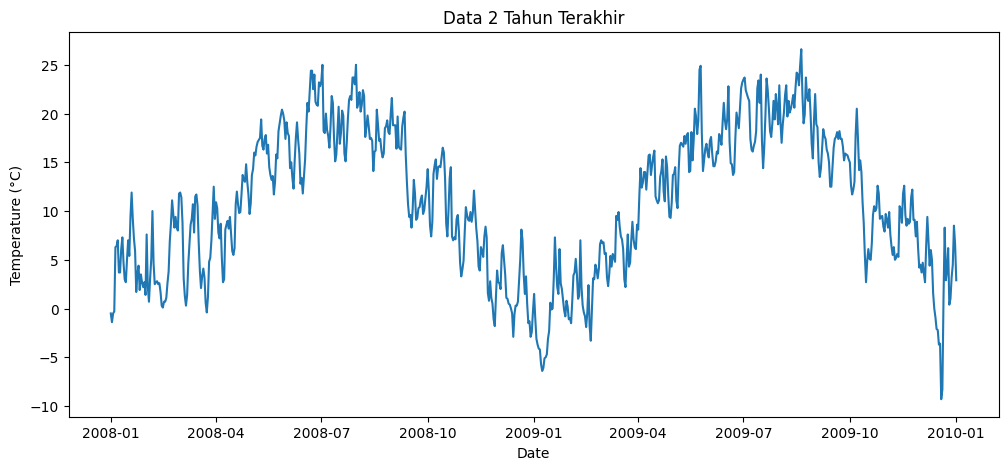

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df_2yr["BASEL_temp_mean"])
plt.title("Data 2 Tahun Terakhir")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()


# **ACF dan PACF**

<Figure size 1200x400 with 0 Axes>

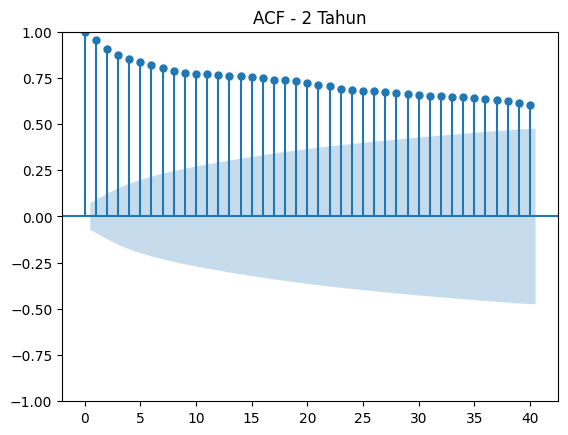

<Figure size 1200x400 with 0 Axes>

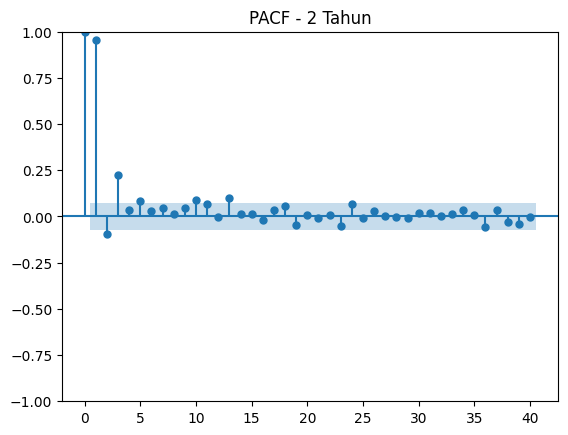

In [ ]:
y = df_2yr["BASEL_temp_mean"]

plt.figure(figsize=(12,4))
plot_acf(y, lags=40)
plt.title("ACF - 2 Tahun")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(y, lags=40, method="ywm")
plt.title("PACF - 2 Tahun")
plt.show()




1.   p = 1 karena PACF menunjukkan cut-off pada lag 1 (spike signifikan pada lag 1, lalu drop)
2.   d = 1 karena data punya trend
3. q = 0 karena ACF tidak menunjukkan cut-off jelas di lag kecil



# **cek stasioner mean dan var**

In [ ]:
def cek_stasioner_mean_var(data, threshold_mean=0.05, threshold_var=0.10):
    data = np.array(data)

    midpoint = len(data) // 2
    part1 = data[:midpoint]
    part2 = data[midpoint:]

    mean1, mean2 = np.mean(part1), np.mean(part2)
    var1, var2 = np.var(part1), np.var(part2)

    mean_change = abs(mean2 - mean1) / (abs(mean1) + 1e-8)
    var_change = abs(var2 - var1) / (abs(var1) + 1e-8)

    print(f"Mean Bagian 1 : {mean1:.4f}")
    print(f"Mean Bagian 2 : {mean2:.4f}")
    print(f"Perubahan Mean: {mean_change*100:.2f}%")

    print(f"\nVarians Bagian 1 : {var1:.4f}")
    print(f"Varians Bagian 2 : {var2:.4f}")
    print(f"Perubahan Varians: {var_change*100:.2f}%")

In [ ]:
cek_stasioner_mean_var(df_2yr["BASEL_temp_mean"])

Mean Bagian 1 : 10.7959
Mean Bagian 2 : 11.1484
Perubahan Mean: 3.26%

Varians Bagian 1 : 48.0110
Varians Bagian 2 : 60.2981
Perubahan Varians: 25.59%


data stasioner menurut mean, dan tidak stasioner menurut var tapi masih dalam batas wajar

# **membuat model sarima dan arima**

In [ ]:
model_arima = sm.tsa.ARIMA(y, order=(1,1,0)).fit()
print(model_arima.summary())


                               SARIMAX Results                                
Dep. Variable:        BASEL_temp_mean   No. Observations:                  732
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -1586.577
Date:                Thu, 20 Nov 2025   AIC                           3177.154
Time:                        05:15:46   BIC                           3186.342
Sample:                    01-01-2008   HQIC                          3180.699
                         - 01-01-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0819      0.032      2.563      0.010       0.019       0.145
sigma2         4.4949      0.194     23.161      0.000       4.115       4.875
Ljung-Box (L1) (Q):                   0.32   Jarque-

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
model_sarima = sm.tsa.statespace.SARIMAX(
    y,
    order=(1,1,0),
    seasonal_order=(1,1,0,30),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

print(model_sarima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                    BASEL_temp_mean   No. Observations:                  732
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 30)   Log Likelihood               -1584.597
Date:                            Thu, 20 Nov 2025   AIC                           3175.195
Time:                                    05:15:48   BIC                           3188.717
Sample:                                01-01-2008   HQIC                          3180.432
                                     - 01-01-2010                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1012      0.037      2.719      0.007       0.028       0.174
ar.S.L30      -0.5131      0.035   

# **evaluasi**

In [ ]:
print("ARIMA AIC:", model_arima.aic)
print("ARIMA BIC:", model_arima.bic)
print("SARIMA AIC:", model_sarima.aic)
print("SARIMA BIC:", model_sarima.bic)


ARIMA AIC: 3177.1536367373164
ARIMA BIC: 3186.342463656816
SARIMA AIC: 3175.1947853482725
SARIMA BIC: 3188.7166184854277


# **forecast 14 hari**

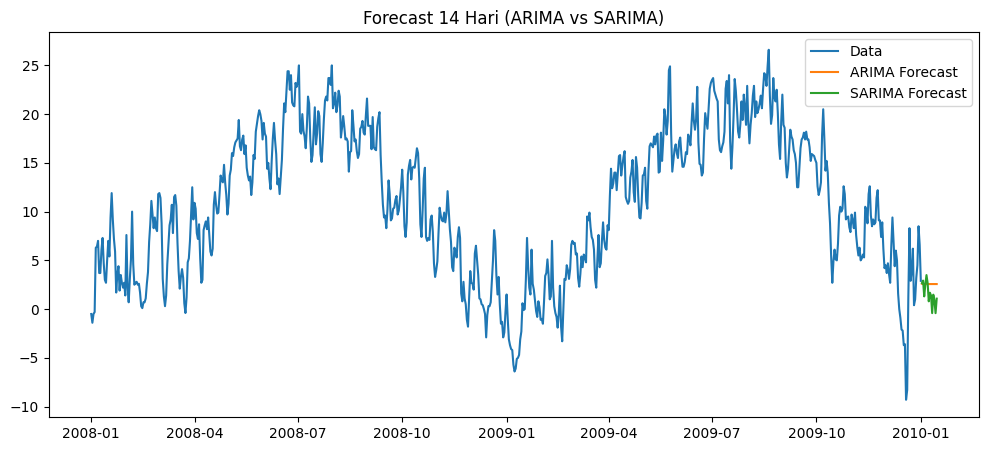

In [ ]:
forecast_arima = model_arima.forecast(14)
forecast_sarima = model_sarima.forecast(14)

plt.figure(figsize=(12,5))
plt.plot(y.index, y, label="Data")
plt.plot(pd.date_range(y.index[-1], periods=15, freq="D")[1:],
         forecast_arima, label="ARIMA Forecast")
plt.plot(pd.date_range(y.index[-1], periods=15, freq="D")[1:],
         forecast_sarima, label="SARIMA Forecast")
plt.title("Forecast 14 Hari (ARIMA vs SARIMA)")
plt.legend()
plt.show()